In [1]:
import pandas as pd

import random
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import euclidean_distances
import missingno

import sys

sys.path.insert(0, "../../utils")

from modules import create_grid
from plots import *
from string_handling import *

enc = 'utf-8' 

random.seed(0)
np.random.seed(0)

pd.set_option('display.max_columns', None)

In [2]:
shapefile_path = "../../../../../Shapefiles/Cameroon Shapefiles/new/"

In [3]:
cameroon_nord_gdf = gpd.read_file(f"{shapefile_path}Nord_region_Level0.shp",  encoding=enc)

In [4]:
cameroon_nord_gdf.head()

,GID_1,GID_0,Pays,Nom_Region,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO_1,geometry
0,CMR.7_1,CMR,Cameroon,Nord,North,NA,Région,Region,NA,CM.NO,CM-NO,"POLYGON ((14.70769 7.02130, 14.70464 7.02077, ..."


In [5]:
cameroon_nord_gdf = cameroon_nord_gdf.to_crs(epsg=4326)
cameroon_nord_gdf.drop(columns=['GID_1',
                                'VARNAME_1',
                                'NL_NAME_1',
                                'TYPE_1',
                                'ENGTYPE_1',
                                'CC_1',
                                'HASC_1',
                                'ISO_1'], inplace = True)

cameroon_nord_gdf.rename(columns={"GID_0" : "div0_code", "Pays": "div0_name", "Nom_Region": "div1_name"}, inplace = True)
cameroon_nord_gdf['div1_code'] = 'NOR'
cameroon_nord_gdf = cameroon_nord_gdf[['div0_code', 'div0_name', 'div1_code', 'div1_name', 'geometry']].copy()


In [6]:
cameroon_nord_gdf['div0_name'] = cameroon_nord_gdf['div0_name'].str.lower()
cameroon_nord_gdf['div0_name'] = cameroon_nord_gdf['div0_name'].apply(lambda x : remove_accents(x))

cameroon_nord_gdf['div1_name'] = cameroon_nord_gdf['div1_name'].str.lower()
cameroon_nord_gdf['div1_name'] = cameroon_nord_gdf['div1_name'].apply(lambda x : remove_accents(x))

In [7]:
cameroon_nord_gdf.head()

,div0_code,div0_name,div1_code,div1_name,geometry
0,CMR,cameroon,NOR,nord,"POLYGON ((14.70769 7.02130, 14.70464 7.02077, ..."


<Axes: >

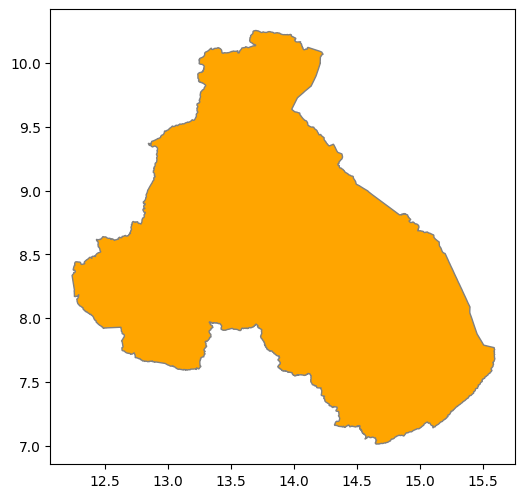

In [8]:
cameroon_nord_gdf.plot(facecolor="none", edgecolor='grey', figsize=(6,6), color='orange')

In [9]:
cameroon_nord_lv3 = gpd.read_file(f"{shapefile_path}Nord_region_Level3.shp",  encoding=enc)

In [10]:
cameroon_nord_lv3.head()

,OBJECTID,Nom_AS,Code_AS,District_S,Code_DS,Nom_Arrond,Code_Arron,Nom_Dept,Code_Dept,Nom_Region,Code_Reg,Id_Arrond,Pays,Code_RS,Id_DS,AVS,Autre_nom,Eff_AVS,Noms_AVS,A_statuer,No_decret,Date_creat,TITRE,Superficie,geometry
0,861,Gor,04TCH04,Tchollire,TCH,Madingring,04 04 04,Mayo-Rey,04 04,Nord,04,A185,Cameroun,NOR,182,None,None,0,None,None,None,None,GOR,6.364798e+08,"POLYGON ((14.82946 8.80523, 14.82959 8.80542, ..."
1,862,Kali,04TCH02,Tchollire,TCH,Tchollire,04 04 01,Mayo-Rey,04 04,Nord,04,A328,Cameroun,NOR,182,None,None,0,None,None,None,None,KALI,1.520400e+09,"POLYGON ((14.25497 8.47303, 14.25528 8.47297, ..."
2,863,Tchollire,04TCH01,Tchollire,TCH,Tchollire,04 04 01,Mayo-Rey,04 04,Nord,04,A328,Cameroun,NOR,182,None,None,0,None,None,None,None,TCHOLLIRE,2.045532e+09,"POLYGON ((14.10170 8.52491, 14.10191 8.52468, ..."
3,864,Gamba,04TCH09,Tchollire,TCH,Tchollire,04 04 01,Mayo-Rey,04 04,Nord,04,A328,Cameroun,NOR,182,None,None,0,None,None,None,None,GAMBA,1.525708e+09,"POLYGON ((13.73985 8.05249, 13.74000 8.05274, ..."
4,865,Sakdjé,04TCH08,Tchollire,TCH,Tchollire,04 04 01,Mayo-Rey,04 04,Nord,04,A328,Cameroun,NOR,182,None,None,0,None,None,None,None,SAKDJÉ,6.539222e+08,"POLYGON ((13.61775 8.35648, 13.61863 8.35606, ..."


In [11]:
cameroon_nord_lv3 = cameroon_nord_lv3.to_crs(epsg=4326)
cameroon_nord_lv3.drop(columns=['Superficie', 'TITRE', 'Date_creat','No_decret','Noms_AVS','Eff_AVS','Autre_nom','AVS', 'Id_DS', 'A_statuer',
                                'Id_Arrond', 'Code_Reg', 'OBJECTID'] , inplace = True )
                            
cameroon_nord_lv3.rename(columns={"Pays": "div0_name", 
                                  
                                  "Nom_Region": "div1_name", 
                                  "Nom_Dept" : "div2_name",
                                  "District_S": "div3_name",
                                  "Nom_AS": "div4_name",

                                  "Code_RS": "div1_code", 
                                  "Code_Dept": "div2_code",  
                                  "Code_DS": "div3_code",
                                  "Code_AS": "div4_code" }, inplace = True)


cameroon_nord_lv3['div0_code'] = 'CMR'

cameroon_nord_lv3['div0_name'] = cameroon_nord_lv3['div0_name'].str.lower()
cameroon_nord_lv3['div0_name'] = cameroon_nord_lv3['div0_name'].apply(lambda x : remove_accents(x))
cameroon_nord_lv3['div1_name'] = cameroon_nord_lv3['div1_name'].str.lower()
cameroon_nord_lv3['div1_name'] = cameroon_nord_lv3['div1_name'].apply(lambda x : remove_accents(x))
cameroon_nord_lv3['div2_name'] = cameroon_nord_lv3['div2_name'].str.lower()
cameroon_nord_lv3['div2_name'] = cameroon_nord_lv3['div2_name'].apply(lambda x : remove_accents(x))
cameroon_nord_lv3['div3_name'] = cameroon_nord_lv3['div3_name'].str.lower()
cameroon_nord_lv3['div3_name'] = cameroon_nord_lv3['div3_name'].apply(lambda x : remove_accents(x))
cameroon_nord_lv3['div4_name'] = cameroon_nord_lv3['div4_name'].str.lower()
cameroon_nord_lv3['div4_name'] = cameroon_nord_lv3['div4_name'].apply(lambda x : remove_accents(x))

In [12]:
cameroon_nord_lv3 = cameroon_nord_lv3[['div0_name', 'div1_name', 'div2_name', 'div3_name', 'div4_name', 'div0_code', 'div1_code', 'div2_code', 'div3_code', 'div4_code', 'geometry']].copy()

In [13]:
cameroon_nord_lv3.head()

,div0_name,div1_name,div2_name,div3_name,div4_name,div0_code,div1_code,div2_code,div3_code,div4_code,geometry
0,cameroun,nord,mayo-rey,tchollire,gor,CMR,NOR,04 04,TCH,04TCH04,"POLYGON ((14.82946 8.80523, 14.82959 8.80542, ..."
1,cameroun,nord,mayo-rey,tchollire,kali,CMR,NOR,04 04,TCH,04TCH02,"POLYGON ((14.25497 8.47303, 14.25528 8.47297, ..."
2,cameroun,nord,mayo-rey,tchollire,tchollire,CMR,NOR,04 04,TCH,04TCH01,"POLYGON ((14.10170 8.52491, 14.10191 8.52468, ..."
3,cameroun,nord,mayo-rey,tchollire,gamba,CMR,NOR,04 04,TCH,04TCH09,"POLYGON ((13.73985 8.05249, 13.74000 8.05274, ..."
4,cameroun,nord,mayo-rey,tchollire,sakdje,CMR,NOR,04 04,TCH,04TCH08,"POLYGON ((13.61775 8.35648, 13.61863 8.35606, ..."


<Axes: >

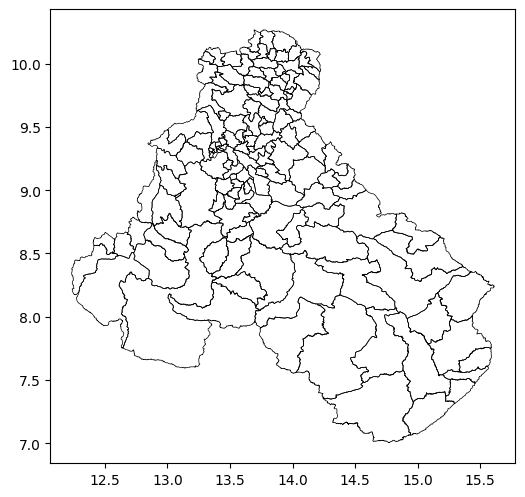

In [14]:
cameroon_nord_lv3.plot(facecolor="none", edgecolor='black', lw=0.5, figsize=(6,6), color='none')

In [15]:
empty_gdf = gpd.GeoDataFrame(columns=['geometry'], geometry='geometry', crs='EPSG:4326')

In [16]:
df_grid_nord_d4 = create_grid(empty_gdf, cameroon_nord_gdf, col_municipal='div0_name', dimension=4)

e:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\notebooks\Nord\../../utils\modules.py:34: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
  river_shapes_list =  river_shapes[col_geometry].geometry.explode().tolist()


In [17]:
df_grid_nord_d4.head()

,geometry,centers,div0_name,x,y,resolution_km
0,"POLYGON ((12.31116 8.20176, 12.31116 8.23769, ...",POINT (12.29305812471719 8.219721878214491),cameroon,12.29306,8.21972,4
1,"POLYGON ((12.31116 8.23769, 12.31116 8.27362, ...",POINT (12.29305812471719 8.255655261414917),cameroon,12.29306,8.25566,4
2,"POLYGON ((12.31116 8.27362, 12.31116 8.30956, ...",POINT (12.29305812471719 8.291588644615345),cameroon,12.29306,8.29159,4
3,"POLYGON ((12.31116 8.30956, 12.31116 8.34549, ...",POINT (12.29305812471719 8.327522027815775),cameroon,12.29306,8.32752,4
4,"POLYGON ((12.31116 8.34549, 12.31116 8.38142, ...",POINT (12.29305812471719 8.3634554110162),cameroon,12.29306,8.36346,4


In [18]:
df_grid_nord_d4.shape

(3961, 6)

<Axes: >

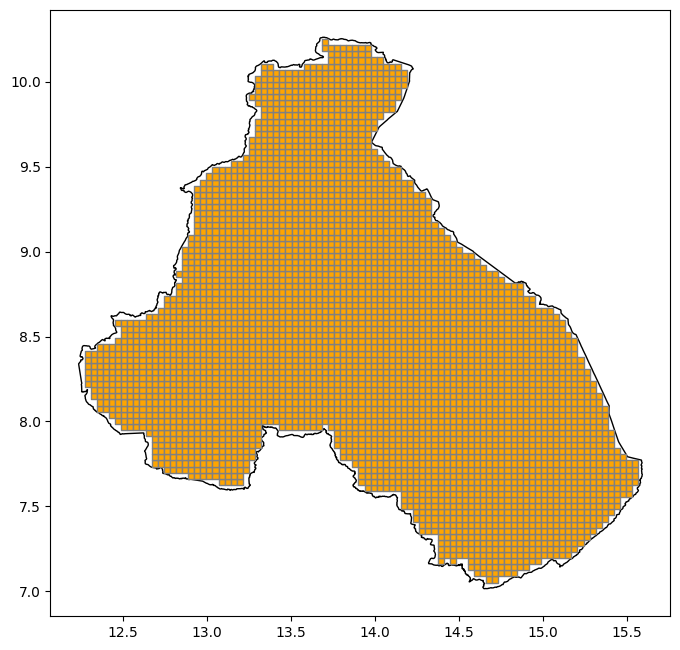

In [19]:
ax = cameroon_nord_gdf.plot(figsize=(8, 8), facecolor="none", edgecolor='black', lw=1)
df_grid_nord_d4.plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')

In [20]:
df_grid_nord_d4.set_geometry('centers', inplace=True)
df_grid_nord_d4.set_crs(epsg=4326, inplace=True)

,geometry,centers,div0_name,x,y,resolution_km
0,"POLYGON ((12.31116 8.20176, 12.31116 8.23769, ...",POINT (12.29306 8.21972),cameroon,12.29306,8.21972,4
1,"POLYGON ((12.31116 8.23769, 12.31116 8.27362, ...",POINT (12.29306 8.25566),cameroon,12.29306,8.25566,4
2,"POLYGON ((12.31116 8.27362, 12.31116 8.30956, ...",POINT (12.29306 8.29159),cameroon,12.29306,8.29159,4
3,"POLYGON ((12.31116 8.30956, 12.31116 8.34549, ...",POINT (12.29306 8.32752),cameroon,12.29306,8.32752,4
4,"POLYGON ((12.31116 8.34549, 12.31116 8.38142, ...",POINT (12.29306 8.36346),cameroon,12.29306,8.36346,4
...,...,...,...,...,...,...
3956,"POLYGON ((15.53336 7.73462, 15.53336 7.77055, ...",POINT (15.51526 7.75259),cameroon,15.51526,7.75259,4
3957,"POLYGON ((15.56956 7.62682, 15.56956 7.66275, ...",POINT (15.55146 7.64479),cameroon,15.55146,7.64479,4
3958,"POLYGON ((15.56956 7.66275, 15.56956 7.69869, ...",POINT (15.55146 7.68072),cameroon,15.55146,7.68072,4
3959,"POLYGON ((15.56956 7.69869, 15.56956 7.73462, ...",POINT (15.55146 7.71665),cameroon,15.55146,7.71665,4


In [21]:
cameroon_nord_grid = gpd.sjoin(df_grid_nord_d4, cameroon_nord_lv3, how='left', op='within')

c:\Users\dimit\Python Virtual Environments\noa_eywa\Lib\site-packages\IPython\core\interactiveshell.py:3517: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  if await self.run_code(code, result, async_=asy):


In [22]:
cameroon_nord_grid.head()

,geometry,centers,div0_name_left,x,y,resolution_km,index_right,div0_name_right,div1_name,div2_name,div3_name,div4_name,div0_code,div1_code,div2_code,div3_code,div4_code
0,"POLYGON ((12.31116 8.20176, 12.31116 8.23769, ...",POINT (12.29306 8.21972),cameroon,12.29306,8.21972,4,133.0,cameroun,nord,faro,poli,balkossa,CMR,NOR,04 03,POL,04POL01
1,"POLYGON ((12.31116 8.23769, 12.31116 8.27362, ...",POINT (12.29306 8.25566),cameroon,12.29306,8.25566,4,133.0,cameroun,nord,faro,poli,balkossa,CMR,NOR,04 03,POL,04POL01
2,"POLYGON ((12.31116 8.27362, 12.31116 8.30956, ...",POINT (12.29306 8.29159),cameroon,12.29306,8.29159,4,133.0,cameroun,nord,faro,poli,balkossa,CMR,NOR,04 03,POL,04POL01
3,"POLYGON ((12.31116 8.30956, 12.31116 8.34549, ...",POINT (12.29306 8.32752),cameroon,12.29306,8.32752,4,133.0,cameroun,nord,faro,poli,balkossa,CMR,NOR,04 03,POL,04POL01
4,"POLYGON ((12.31116 8.34549, 12.31116 8.38142, ...",POINT (12.29306 8.36346),cameroon,12.29306,8.36346,4,133.0,cameroun,nord,faro,poli,balkossa,CMR,NOR,04 03,POL,04POL01


In [23]:
cameroon_nord_grid.dropna(inplace=True)

In [24]:
final_grid = cameroon_nord_grid[['x', 'y', 'div0_name_right', 'div1_name', 'div2_name', 'div3_name', 'div4_name', 'div0_code', 'div1_code', 'div2_code', 'div3_code', 'div4_code', 'resolution_km', 'centers', 'geometry']].copy()
final_grid.set_geometry('geometry', inplace=True)
final_grid.rename(columns={'div0_name_right': "div0_name"}, inplace=True)
final_grid.sort_values(by=['x', 'y', 'div4_name'], inplace = True)
final_grid.reset_index(drop=True, inplace=True)

<Axes: >

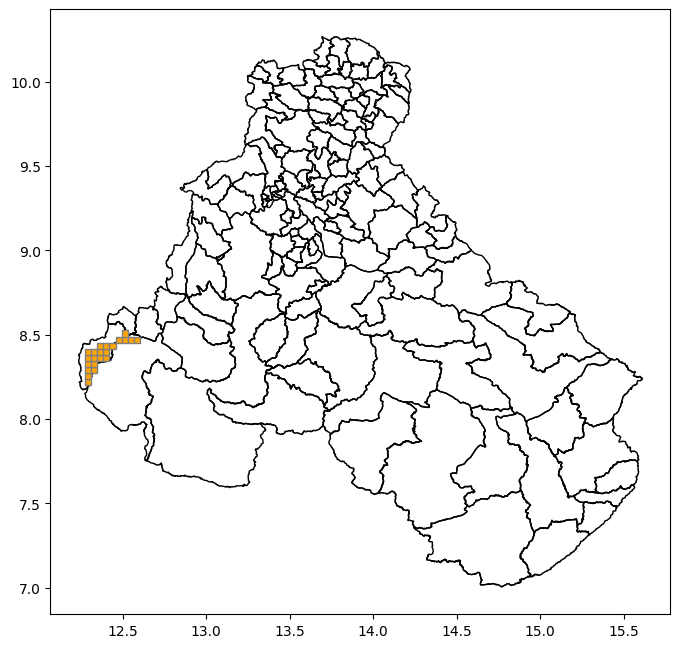

In [25]:
ax = cameroon_nord_lv3.plot(figsize=(8, 8), facecolor="none", edgecolor='black', lw=1)
final_grid[final_grid['div4_name'] == 'balkossa'].plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')

In [26]:
final_grid

,x,y,div0_name,div1_name,div2_name,div3_name,div4_name,div0_code,div1_code,div2_code,div3_code,div4_code,resolution_km,centers,geometry
0,12.29306,8.21972,cameroun,nord,faro,poli,balkossa,CMR,NOR,04 03,POL,04POL01,4,POINT (12.29306 8.21972),"POLYGON ((12.31116 8.20176, 12.31116 8.23769, ..."
1,12.29306,8.25566,cameroun,nord,faro,poli,balkossa,CMR,NOR,04 03,POL,04POL01,4,POINT (12.29306 8.25566),"POLYGON ((12.31116 8.23769, 12.31116 8.27362, ..."
2,12.29306,8.29159,cameroun,nord,faro,poli,balkossa,CMR,NOR,04 03,POL,04POL01,4,POINT (12.29306 8.29159),"POLYGON ((12.31116 8.27362, 12.31116 8.30956, ..."
3,12.29306,8.32752,cameroun,nord,faro,poli,balkossa,CMR,NOR,04 03,POL,04POL01,4,POINT (12.29306 8.32752),"POLYGON ((12.31116 8.30956, 12.31116 8.34549, ..."
4,12.29306,8.36346,cameroun,nord,faro,poli,balkossa,CMR,NOR,04 03,POL,04POL01,4,POINT (12.29306 8.36346),"POLYGON ((12.31116 8.34549, 12.31116 8.38142, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3950,15.51526,7.75259,cameroun,nord,mayo-rey,touboro,touboro,CMR,NOR,04 04,TOU,04TOU09,4,POINT (15.51526 7.75259),"POLYGON ((15.53336 7.73462, 15.53336 7.77055, ..."
3951,15.55146,7.64479,cameroun,nord,mayo-rey,touboro,mafare,CMR,NOR,04 04,TOU,04TOU03,4,POINT (15.55146 7.64479),"POLYGON ((15.56956 7.62682, 15.56956 7.66275, ..."
3952,15.55146,7.68072,cameroun,nord,mayo-rey,touboro,mafare,CMR,NOR,04 04,TOU,04TOU03,4,POINT (15.55146 7.68072),"POLYGON ((15.56956 7.66275, 15.56956 7.69869, ..."
3953,15.55146,7.71665,cameroun,nord,mayo-rey,touboro,mafare,CMR,NOR,04 04,TOU,04TOU03,4,POINT (15.55146 7.71665),"POLYGON ((15.56956 7.69869, 15.56956 7.73462, ..."


In [27]:
print(f'Shape of final_grid: {final_grid.div4_name.unique().shape}')
print(f'Shape of cameroon_nord_lv3: {cameroon_nord_lv3.div4_name.unique().shape}')

Shape of final_grid: (142,)
Shape of cameroon_nord_lv3: (144,)


In [28]:
diff = list(set(cameroon_nord_lv3.div4_name.unique().tolist()) - set(final_grid.div4_name.unique().tolist()))
print(f'Difference is: {len(diff)}')
print(f'Missing GIDs are: {diff}') 

Difference is: 2
Missing GIDs are: ['roumde adjia', 'foulbere']


In [29]:
missing_GIDs_d4 = cameroon_nord_lv3[cameroon_nord_lv3.div4_name.isin(diff)].copy()
missing_GIDs_d4.reset_index(drop=True, inplace=True)

In [30]:
missing_GIDs_d4

,div0_name,div1_name,div2_name,div3_name,div4_name,div0_code,div1_code,div2_code,div3_code,div4_code,geometry
0,cameroun,nord,benoue,garoua 2,foulbere,CMR,NOR,04 01,GAA,04GAA01,"POLYGON ((13.40616 9.29529, 13.40603 9.29544, ..."
1,cameroun,nord,benoue,garoua 2,roumde adjia,CMR,NOR,04 01,GAA,04GAA05,"POLYGON ((13.39302 9.31609, 13.39276 9.31667, ..."


In [31]:
df_grid_nord_d1= create_grid(empty_gdf, missing_GIDs_d4, col_municipal='div1_name', dimension=1)

e:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\notebooks\Nord\../../utils\modules.py:34: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
  river_shapes_list =  river_shapes[col_geometry].geometry.explode().tolist()


In [32]:
df_grid_nord_d1.head()

,geometry,centers,div1_name,x,y,resolution_km
0,"POLYGON ((13.41380 9.30427, 13.41380 9.31325, ...",POINT (13.40924895541995 9.308762395700183),nord,13.40925,9.30876,1
1,"POLYGON ((13.42290 9.30427, 13.42290 9.31325, ...",POINT (13.418351831033217 9.308762395700183),nord,13.41835,9.30876,1
2,"POLYGON ((13.43201 9.30427, 13.43201 9.31325, ...",POINT (13.427454706646486 9.308762395700183),nord,13.42745,9.30876,1


In [33]:
df_grid_nord_d1.shape

(3, 6)

<Axes: >

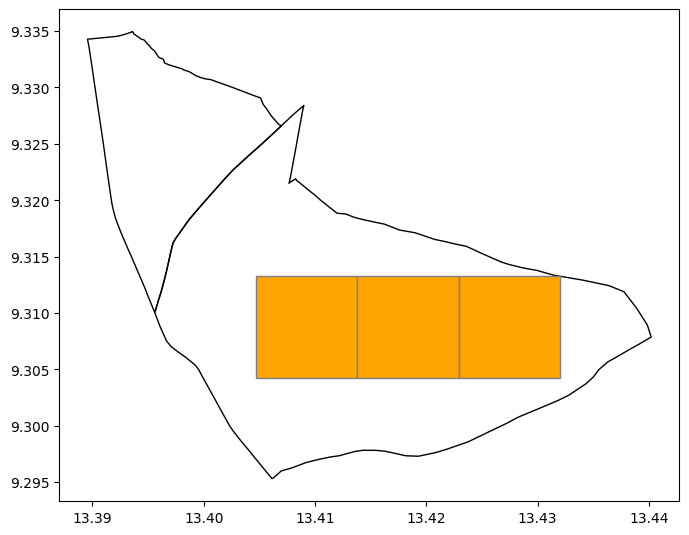

In [34]:
ax = missing_GIDs_d4.plot(figsize=(8, 8), facecolor="none", edgecolor='black', lw=1)
df_grid_nord_d1.plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')

In [35]:
df_grid_nord_d1.set_geometry('centers', inplace=True)
df_grid_nord_d1.set_crs(epsg=4326, inplace=True)

,geometry,centers,div1_name,x,y,resolution_km
0,"POLYGON ((13.41380 9.30427, 13.41380 9.31325, ...",POINT (13.40925 9.30876),nord,13.40925,9.30876,1
1,"POLYGON ((13.42290 9.30427, 13.42290 9.31325, ...",POINT (13.41835 9.30876),nord,13.41835,9.30876,1
2,"POLYGON ((13.43201 9.30427, 13.43201 9.31325, ...",POINT (13.42745 9.30876),nord,13.42745,9.30876,1


In [36]:
cameroon_nord_second_grid = gpd.sjoin(df_grid_nord_d1, missing_GIDs_d4, how='left', op='within')

c:\Users\dimit\Python Virtual Environments\noa_eywa\Lib\site-packages\IPython\core\interactiveshell.py:3517: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  if await self.run_code(code, result, async_=asy):


In [37]:
cameroon_nord_second_grid.head()

,geometry,centers,div1_name_left,x,y,resolution_km,index_right,div0_name,div1_name_right,div2_name,div3_name,div4_name,div0_code,div1_code,div2_code,div3_code,div4_code
0,"POLYGON ((13.41380 9.30427, 13.41380 9.31325, ...",POINT (13.40925 9.30876),nord,13.40925,9.30876,1,0,cameroun,nord,benoue,garoua 2,foulbere,CMR,NOR,04 01,GAA,04GAA01
1,"POLYGON ((13.42290 9.30427, 13.42290 9.31325, ...",POINT (13.41835 9.30876),nord,13.41835,9.30876,1,0,cameroun,nord,benoue,garoua 2,foulbere,CMR,NOR,04 01,GAA,04GAA01
2,"POLYGON ((13.43201 9.30427, 13.43201 9.31325, ...",POINT (13.42745 9.30876),nord,13.42745,9.30876,1,0,cameroun,nord,benoue,garoua 2,foulbere,CMR,NOR,04 01,GAA,04GAA01


In [38]:
cameroon_nord_second_grid.dropna(inplace=True)

In [39]:
cameroon_nord_second_grid = cameroon_nord_second_grid[['x', 'y', 'div0_name', 'div1_name_right', 'div2_name', 'div3_name', 'div4_name', 'div0_code', 'div1_code', 'div2_code', 'div3_code', 'div4_code', 'resolution_km', 'centers', 'geometry']].copy()
cameroon_nord_second_grid.set_geometry('geometry', inplace=True)
cameroon_nord_second_grid.rename(columns={'div1_name_right': "div1_name"}, inplace=True)
cameroon_nord_second_grid.sort_values(by=['x', 'y', 'div4_name'], inplace = True)
cameroon_nord_second_grid.reset_index(drop=True, inplace=True)

In [40]:
cameroon_nord_second_grid

,x,y,div0_name,div1_name,div2_name,div3_name,div4_name,div0_code,div1_code,div2_code,div3_code,div4_code,resolution_km,centers,geometry
0,13.40925,9.30876,cameroun,nord,benoue,garoua 2,foulbere,CMR,NOR,04 01,GAA,04GAA01,1,POINT (13.40925 9.30876),"POLYGON ((13.41380 9.30427, 13.41380 9.31325, ..."
1,13.41835,9.30876,cameroun,nord,benoue,garoua 2,foulbere,CMR,NOR,04 01,GAA,04GAA01,1,POINT (13.41835 9.30876),"POLYGON ((13.42290 9.30427, 13.42290 9.31325, ..."
2,13.42745,9.30876,cameroun,nord,benoue,garoua 2,foulbere,CMR,NOR,04 01,GAA,04GAA01,1,POINT (13.42745 9.30876),"POLYGON ((13.43201 9.30427, 13.43201 9.31325, ..."


In [41]:
final_grid = pd.concat([final_grid, cameroon_nord_second_grid], ignore_index=True)

In [42]:
print(f'Shape of final_grid: {final_grid.div4_name.unique().shape}')
print(f'Shape of cameroon_nord_lv3: {cameroon_nord_lv3.div4_name.unique().shape}')

Shape of final_grid: (143,)
Shape of cameroon_nord_lv3: (144,)


In [43]:
diff = list(set(cameroon_nord_lv3.div4_name.unique().tolist()) - set(final_grid.div4_name.unique().tolist()))
print(f'Difference is: {len(diff)}')
print(f'Missing GIDs are: {diff}') 

Difference is: 1
Missing GIDs are: ['roumde adjia']


In [44]:
missing_GIDs_d1 = cameroon_nord_lv3[cameroon_nord_lv3.div4_name.isin(diff)].copy()
missing_GIDs_d1.reset_index(drop=True, inplace=True)

In [45]:
missing_GIDs_d1

,div0_name,div1_name,div2_name,div3_name,div4_name,div0_code,div1_code,div2_code,div3_code,div4_code,geometry
0,cameroun,nord,benoue,garoua 2,roumde adjia,CMR,NOR,04 01,GAA,04GAA05,"POLYGON ((13.39302 9.31609, 13.39276 9.31667, ..."


In [46]:
missing_GIDs_d1["centers"] = missing_GIDs_d1.geometry.centroid

C:\Users\dimit\AppData\Local\Temp\ipykernel_15736\1981699749.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  missing_GIDs_d1["centers"] = missing_GIDs_d1.geometry.centroid


In [47]:
missing_GIDs_d1

,div0_name,div1_name,div2_name,div3_name,div4_name,div0_code,div1_code,div2_code,div3_code,div4_code,geometry,centers
0,cameroun,nord,benoue,garoua 2,roumde adjia,CMR,NOR,04 01,GAA,04GAA05,"POLYGON ((13.39302 9.31609, 13.39276 9.31667, ...",POINT (13.39663 9.32491)


In [48]:
missing_GIDs_d1['resolution_km'] = 0.7

<Axes: >

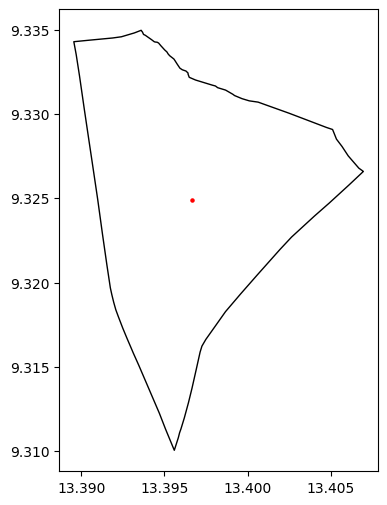

In [49]:
ax = missing_GIDs_d1.plot(edgecolor='black', facecolor='none', figsize=(6, 6))
missing_GIDs_d1['centers'].plot(ax=ax, color='red', markersize=5)

In [50]:
missing_GIDs_d1["x"] = missing_GIDs_d1["centers"].x
missing_GIDs_d1["y"] = missing_GIDs_d1["centers"].y
missing_GIDs_d1 = missing_GIDs_d1[['x', 'y', 'div0_name', 'div1_name', 'div2_name', 'div3_name', 'div4_name', 'div0_code', 'div1_code', 'div2_code', 'div3_code', 'div4_code', 'resolution_km', 'centers', 'geometry']]


In [51]:
missing_GIDs_d1.head()

,x,y,div0_name,div1_name,div2_name,div3_name,div4_name,div0_code,div1_code,div2_code,div3_code,div4_code,resolution_km,centers,geometry
0,13.396634,9.324907,cameroun,nord,benoue,garoua 2,roumde adjia,CMR,NOR,04 01,GAA,04GAA05,0.7,POINT (13.39663 9.32491),"POLYGON ((13.39302 9.31609, 13.39276 9.31667, ..."


In [52]:
final_grid = pd.concat([final_grid, missing_GIDs_d1], ignore_index=True)

In [53]:
print(f'Shape of final_grid: {final_grid.div4_name.unique().shape}')
print(f'Shape of cameroon_nord_lv3: {cameroon_nord_lv3.div4_name.unique().shape}')

Shape of final_grid: (144,)
Shape of cameroon_nord_lv3: (144,)


In [54]:
final_grid.sort_values(by=['x', 'y', 'div2_name', 'div3_name', 'div4_name'], inplace = True)
final_grid.rename(columns={'x': 'longitude', 'y': 'latitude'}, inplace=True)
final_grid.reset_index(drop=True, inplace=True)
final_grid.drop(columns=['centers'], inplace=True)
final_grid

,longitude,latitude,div0_name,div1_name,div2_name,div3_name,div4_name,div0_code,div1_code,div2_code,div3_code,div4_code,resolution_km,geometry
0,12.29306,8.21972,cameroun,nord,faro,poli,balkossa,CMR,NOR,04 03,POL,04POL01,4.0,"POLYGON ((12.31116 8.20176, 12.31116 8.23769, ..."
1,12.29306,8.25566,cameroun,nord,faro,poli,balkossa,CMR,NOR,04 03,POL,04POL01,4.0,"POLYGON ((12.31116 8.23769, 12.31116 8.27362, ..."
2,12.29306,8.29159,cameroun,nord,faro,poli,balkossa,CMR,NOR,04 03,POL,04POL01,4.0,"POLYGON ((12.31116 8.27362, 12.31116 8.30956, ..."
3,12.29306,8.32752,cameroun,nord,faro,poli,balkossa,CMR,NOR,04 03,POL,04POL01,4.0,"POLYGON ((12.31116 8.30956, 12.31116 8.34549, ..."
4,12.29306,8.36346,cameroun,nord,faro,poli,balkossa,CMR,NOR,04 03,POL,04POL01,4.0,"POLYGON ((12.31116 8.34549, 12.31116 8.38142, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3954,15.51526,7.75259,cameroun,nord,mayo-rey,touboro,touboro,CMR,NOR,04 04,TOU,04TOU09,4.0,"POLYGON ((15.53336 7.73462, 15.53336 7.77055, ..."
3955,15.55146,7.64479,cameroun,nord,mayo-rey,touboro,mafare,CMR,NOR,04 04,TOU,04TOU03,4.0,"POLYGON ((15.56956 7.62682, 15.56956 7.66275, ..."
3956,15.55146,7.68072,cameroun,nord,mayo-rey,touboro,mafare,CMR,NOR,04 04,TOU,04TOU03,4.0,"POLYGON ((15.56956 7.66275, 15.56956 7.69869, ..."
3957,15.55146,7.71665,cameroun,nord,mayo-rey,touboro,mafare,CMR,NOR,04 04,TOU,04TOU03,4.0,"POLYGON ((15.56956 7.69869, 15.56956 7.73462, ..."


In [55]:
final_grid['div0_name'] = 'cameroon'

In [56]:
if final_grid['div4_code'].isnull().any():
    raise ValueError("div4_code contains NULL values, need rules to handle them.")

# Create a "counter" per div4_code
final_grid['counter'] = final_grid.groupby('div4_code').cumcount() + 1

# Convert counter to hex, padded to 5 digits
final_grid['hex_counter'] = final_grid['counter'].apply(lambda x: format(x, '05X'))

# Final point_code = div4_code + hex_counter
final_grid['point_code'] = final_grid['div4_code'] + final_grid['hex_counter']

# Drop helper columns
final_grid = final_grid.drop(columns=['counter', 'hex_counter'])

In [57]:
final_grid = final_grid[['point_code', 'latitude', 'longitude', 'div0_name', 'div0_code', 'div1_name', 'div1_code', 'div2_name', 'div2_code', 'div3_name', 'div3_code', 'div4_name','div4_code', 'resolution_km', 'geometry']].copy()

<Axes: >

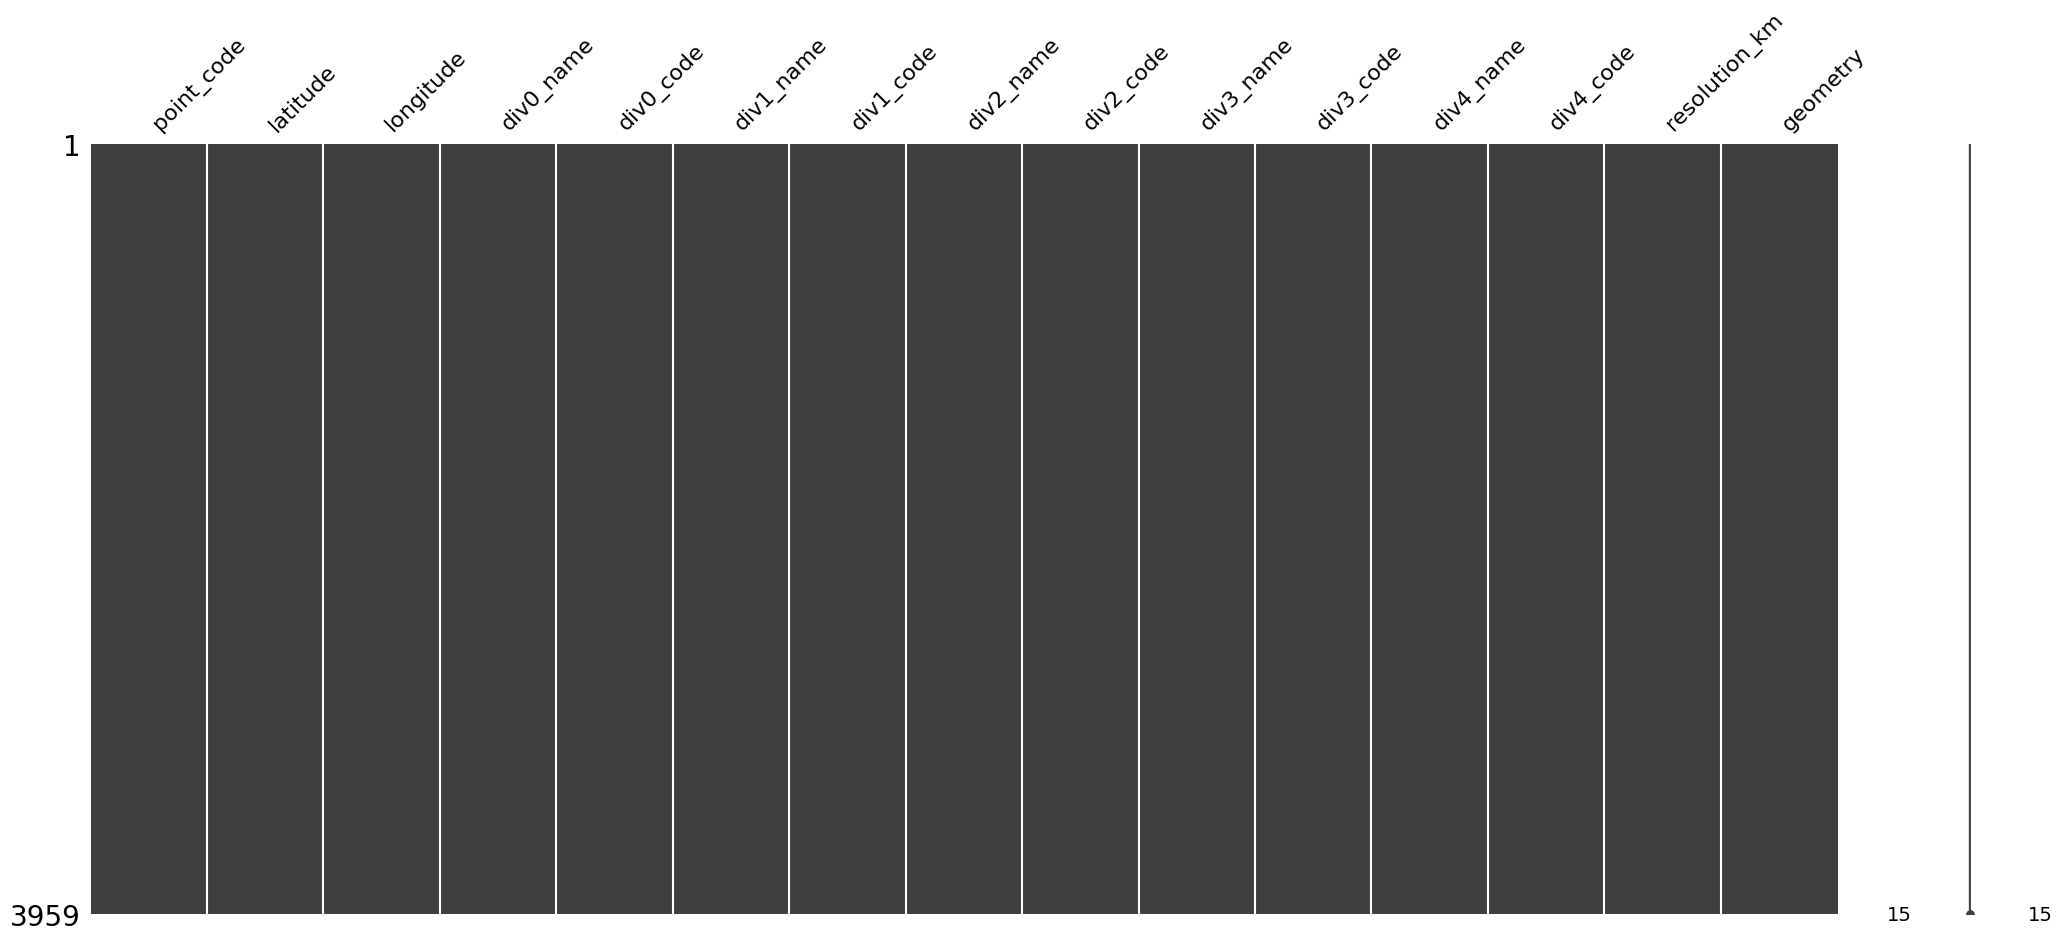

In [58]:
missingno.matrix(final_grid)

In [59]:
final_grid

,point_code,latitude,longitude,div0_name,div0_code,div1_name,div1_code,div2_name,div2_code,div3_name,div3_code,div4_name,div4_code,resolution_km,geometry
0,04POL0100001,8.21972,12.29306,cameroon,CMR,nord,NOR,faro,04 03,poli,POL,balkossa,04POL01,4.0,"POLYGON ((12.31116 8.20176, 12.31116 8.23769, ..."
1,04POL0100002,8.25566,12.29306,cameroon,CMR,nord,NOR,faro,04 03,poli,POL,balkossa,04POL01,4.0,"POLYGON ((12.31116 8.23769, 12.31116 8.27362, ..."
2,04POL0100003,8.29159,12.29306,cameroon,CMR,nord,NOR,faro,04 03,poli,POL,balkossa,04POL01,4.0,"POLYGON ((12.31116 8.27362, 12.31116 8.30956, ..."
3,04POL0100004,8.32752,12.29306,cameroon,CMR,nord,NOR,faro,04 03,poli,POL,balkossa,04POL01,4.0,"POLYGON ((12.31116 8.30956, 12.31116 8.34549, ..."
4,04POL0100005,8.36346,12.29306,cameroon,CMR,nord,NOR,faro,04 03,poli,POL,balkossa,04POL01,4.0,"POLYGON ((12.31116 8.34549, 12.31116 8.38142, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3954,04TOU0900050,7.75259,15.51526,cameroon,CMR,nord,NOR,mayo-rey,04 04,touboro,TOU,touboro,04TOU09,4.0,"POLYGON ((15.53336 7.73462, 15.53336 7.77055, ..."
3955,04TOU0300014,7.64479,15.55146,cameroon,CMR,nord,NOR,mayo-rey,04 04,touboro,TOU,mafare,04TOU03,4.0,"POLYGON ((15.56956 7.62682, 15.56956 7.66275, ..."
3956,04TOU0300015,7.68072,15.55146,cameroon,CMR,nord,NOR,mayo-rey,04 04,touboro,TOU,mafare,04TOU03,4.0,"POLYGON ((15.56956 7.66275, 15.56956 7.69869, ..."
3957,04TOU0300016,7.71665,15.55146,cameroon,CMR,nord,NOR,mayo-rey,04 04,touboro,TOU,mafare,04TOU03,4.0,"POLYGON ((15.56956 7.69869, 15.56956 7.73462, ..."


In [61]:
final_grid[final_grid['resolution_km']<4]

,point_code,latitude,longitude,div0_name,div0_code,div1_name,div1_code,div2_name,div2_code,div3_name,div3_code,div4_name,div4_code,resolution_km,geometry
1062,04GAA0500001,9.324907,13.396634,cameroon,CMR,nord,NOR,benoue,04 01,garoua 2,GAA,roumde adjia,04GAA05,0.7,"POLYGON ((13.39302 9.31609, 13.39276 9.31667, ..."
1063,04GAA0100001,9.308760,13.409250,cameroon,CMR,nord,NOR,benoue,04 01,garoua 2,GAA,foulbere,04GAA01,1.0,"POLYGON ((13.41380 9.30427, 13.41380 9.31325, ..."
1122,04GAA0100002,9.308760,13.418350,cameroon,CMR,nord,NOR,benoue,04 01,garoua 2,GAA,foulbere,04GAA01,1.0,"POLYGON ((13.42290 9.30427, 13.42290 9.31325, ..."
1123,04GAA0100003,9.308760,13.427450,cameroon,CMR,nord,NOR,benoue,04 01,garoua 2,GAA,foulbere,04GAA01,1.0,"POLYGON ((13.43201 9.30427, 13.43201 9.31325, ..."


In [60]:
final_grid.drop(columns='geometry').to_csv(f'../../data/CM_Nord_Grid_DB.csv', encoding=enc, index = False)
# final_grid.to_file(f'../data/CM_Nord_Grid.shp', encoding = 'utf-8')